Si consideri il data set sintetico presente nel file data.csv costituito da 3000 punti 
con  15  feature  numeriche  cadauno  e  una  label  binaria  di  classe  con  valori 
appartenenti a {0, 1}. 
 
 
1. Caricare il dataset, estrarre randomicamente un test set pari al 5% dei dati, 
mantenendo il restante 95% come training set vero e proprio. Calcolare e 
stampare la matrice di correlazione tra le feature e trasformare gli eventuali 
dati  multicollineari  con  una  opportuna  combinazione  lineare.  Infine 
selezionare le feature rilevanti tramite il Fisher score. 
punti ___/ 8 
 
 
2. Implementare un classificatore SVM non lineare per il data set curato come 
al punto precedente con i seguenti iperparametri: 
 
• C = {1, 1/sqrt(n_samples)} 
• kernel=RBF e polinomiale 
• grado del kernek polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 8 
 
 
3. Implementare in Tensorflow una piccola rete neurale densa con almeno due 
layer che esegua la classificazione binaria del data set curato, risultato del 
punto 1. Si utilizzi un opportuno ammontare di dropout sui layer densi ad 
esclusione del primo. La rete sarà addestrata con ottimizzatore RMSProp in 
versione “centrata” con weight decay e momento pari 0.1. Si implementino 
le callback di early stopping, con validation set pari al 10% del training set, una 
pazienza  sulla  validation  loss  di  5  epoche  e  un  incremento  minimo  di 
miglioramento pari a 0.01; infine, la modelcheckpoint salverà solo il miglior 
modello rispetto alla massima validation accuracy. 
punti ___/ 10 
 
 
4. Confrontare  i  risultati  dei  due  classificatori  calcolando  e  stampando,  per 
ciascuno, la matrice di confusione, il valore di accuracy, la ROC e il valore di 
AUC calcolati sul test set. 
punti ___/ 4 
 
 
TOTALE: punti ___/ 30 


In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd 

df = pd.read_csv('data.csv')

df = df.dropna(subset=['class'])


X = df.drop( columns= ['class'])

y = df['class']


X_tr,X_te,y_tr,y_te = train_test_split(X,y, test_size=0.5,random_state=42,stratify=df['class'])

print(X_tr.shape)


(1500, 15)


In [3]:
#imputazione

print(X_tr.isna().sum())
#non c'è bisogno di imputazione

feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
dtype: int64


In [4]:
print(X_tr.select_dtypes(include=['number']).columns.tolist())
#tutte le feature sono numeriche

['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14']


In [5]:

#ci sono alcune feature molto distanti rispetto alle altre faccio uno sclaing per sicurezza

from sklearn.preprocessing import StandardScaler

print(X_tr.mean())
print(X_tr.var())

scaler = StandardScaler().set_output(transform='pandas')

X_tr = scaler.fit_transform(X_tr)

X_te = scaler.transform(X_te)




feature_0    -0.004793
feature_1     0.049560
feature_2    -0.006461
feature_3     0.976137
feature_4     0.137377
feature_5     0.027886
feature_6    -0.508202
feature_7     0.048888
feature_8    -0.481102
feature_9     0.006086
feature_10    0.015738
feature_11    0.003727
feature_12    0.044595
feature_13    0.158288
feature_14    0.027166
dtype: float64
feature_0     1.006005
feature_1     1.010182
feature_2     0.970091
feature_3     1.507042
feature_4     6.198243
feature_5     0.980252
feature_6     1.980707
feature_7     2.974681
feature_8     2.646999
feature_9     1.061178
feature_10    1.008290
feature_11    2.420939
feature_12    0.974361
feature_13    3.879776
feature_14    0.971886
dtype: float64



1. Caricare il dataset, estrarre randomicamente un test set pari al 5% dei dati, 
mantenendo il restante 95% come training set vero e proprio. Calcolare e 
stampare la matrice di correlazione tra le feature e trasformare gli eventuali 
dati  multicollineari  con  una  opportuna  combinazione  lineare.  Infine 
selezionare le feature rilevanti tramite il Fisher score. 
punti ___/ 8 

In [5]:


import pandas as pd
import numpy as np

corr_matrix = X_tr.corr().abs()
print(corr_matrix)
threshold = 0.7
feature_comb = []
num_col = len(X_tr.columns)

for i in range(num_col):
    for j in range(i + 1, num_col):
        valore = corr_matrix.iloc[i, j]
        
        if valore > threshold:
            col_comb = corr_matrix.columns[j]
            row_comb = corr_matrix.index[i]  
            
            inserted = False
            for gruppo in feature_comb:
                if col_comb in gruppo or row_comb in gruppo:
                    if col_comb not in gruppo:
                        gruppo.append(col_comb)
                    if row_comb not in gruppo:
                        gruppo.append(row_comb)
                    inserted = True
                    break  
            
            if not inserted:
                feature_comb.append([col_comb, row_comb])

x_tr = X_tr.copy()
x_te = X_te.copy()
col_list = []          

for idx, gruppo in enumerate(feature_comb):
    name_f = f'feature_add_{idx + 1}'
    
    x_tr[name_f] = X_tr[gruppo].mean(axis=1)
    x_te[name_f] = X_te[gruppo].mean(axis=1)
    
    for col in gruppo:
        if col not in col_list:
            col_list.append(col)

X_tr = x_tr.drop(columns=col_list)
X_te = x_te.drop(columns=col_list)

print("Gruppi di feature correlate identificati:", feature_comb)
print(X_tr.shape)

            feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
feature_0    1.000000   0.002487   0.010664   0.010251   0.031333   0.002406   
feature_1    0.002487   1.000000   0.021604   0.035199   0.019585   0.025106   
feature_2    0.010664   0.021604   1.000000   0.014993   0.015505   0.009939   
feature_3    0.010251   0.035199   0.014993   1.000000   0.165261   0.001142   
feature_4    0.031333   0.019585   0.015505   0.165261   1.000000   0.009392   
feature_5    0.002406   0.025106   0.009939   0.001142   0.009392   1.000000   
feature_6    0.009016   0.008975   0.010290   0.071515   0.077510   0.007230   
feature_7    0.054463   0.049441   0.013974   0.076778   0.677119   0.022527   
feature_8    0.007823   0.004828   0.003481   0.204823   0.818096   0.042382   
feature_9    0.027032   0.022779   0.007838   0.012668   0.010402   0.007877   
feature_10   0.047847   0.018868   0.048778   0.012445   0.031779   0.044290   
feature_11   0.017412   0.001514   0.014

Quando utilizzi SelectKBest accoppiato a f_classif (che implementa il test statistico ANOVA), l'algoritmo calcola per ogni singola feature un punteggio basato sul rapporto tra due varianze:$$F = \frac{\text{Varianza Inter-Classe (Between-group Variance)}}{\text{Varianza Intra-Classe (Within-group Variance)}}$$Varianza Inter-Classe (Numeratore): Misura quanto le medie delle diverse classi (es. la classe 0 e la classe 1) siano distanti tra loro lungo l'asse di quella specifica feature. Più le medie sono distanti, più la feature aiuta a separare i gruppi.Varianza Intra-Classe (Denominatore): Misura quanto i punti appartenenti alla stessa classe siano dispersi o "sparpagliati" attorno alla loro media. Più i punti sono compatti (varianza bassa), meglio è.Di conseguenza, uno score molto alto indica una feature eccellente: significa che le classi sono geometricamente ben distanziate tra loro e, al tempo stesso, molto compatte al loro interno.

[np.float64(982.9640945480653), np.float64(194.23293543223153), np.float64(39.91118804165407), np.float64(1.044585347585103), np.float64(0.7298853836853971), np.float64(0.7164439944517043), np.float64(0.5192051480550097), np.float64(0.40545589965678575), np.float64(0.26026278844967093), np.float64(0.16493286474638463), np.float64(0.01304182925947204), np.float64(0.004711810323555537), np.float64(0.0016084694364948515)]


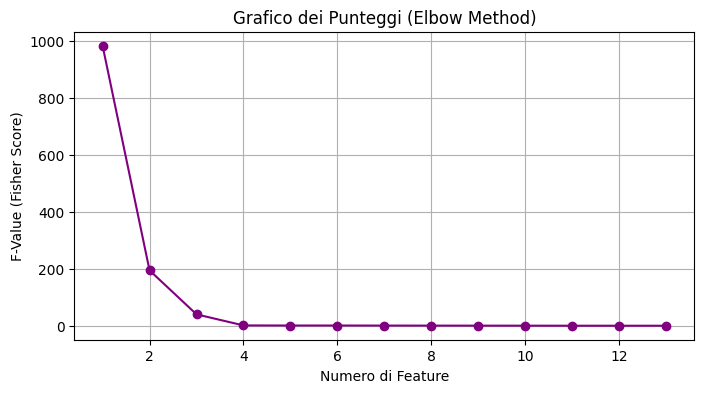

In [7]:


from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

selector = SelectKBest(score_func=f_classif, k='all').fit(X_tr, y_tr)
scores = sorted(selector.scores_, reverse=True)
print(scores)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(scores) + 1), scores, marker='o', color='purple')
plt.title("Grafico dei Punteggi (Elbow Method)")
plt.xlabel("Numero di Feature")
plt.ylabel("F-Value (Fisher Score)")
plt.grid(True)
plt.show()



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=2).set_output(transform='pandas')

X_tr = selector.fit_transform( X_tr, y_tr )
X_te = selector.transform( X_te )

In [9]:
print(X_tr)

      feature_6  feature_11
203   -1.366593    1.614497
2795  -1.193280   -1.315925
2247  -0.500963    0.928665
416    1.070527    0.565384
2000   0.259124    0.970192
...         ...         ...
192    1.246826   -1.702657
1525  -1.086969    0.905623
202   -0.256280   -0.808199
630   -0.979169   -3.811674
526   -0.139347    0.114393

[1500 rows x 2 columns]


2. Implementare un classificatore SVM non lineare per il data set curato come 
al punto precedente con i seguenti iperparametri: 
 
• C = {1, 1/sqrt(n_samples)} 
• kernel=RBF e polinomiale 
• grado del kernek polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 8 

4. Confrontare  i  risultati  dei  due  classificatori  calcolando  e  stampando,  per 
ciascuno, la matrice di confusione, il valore di accuracy, la ROC e il valore di 
AUC calcolati sul test set. 
punti ___/ 4 

Miglior classificatore (CV Accuracy): 0.8687
Iperparametri ottimali: {'C': 1, 'kernel': 'rbf'}
Test Accuracy ottenuta in predizione: 0.8660


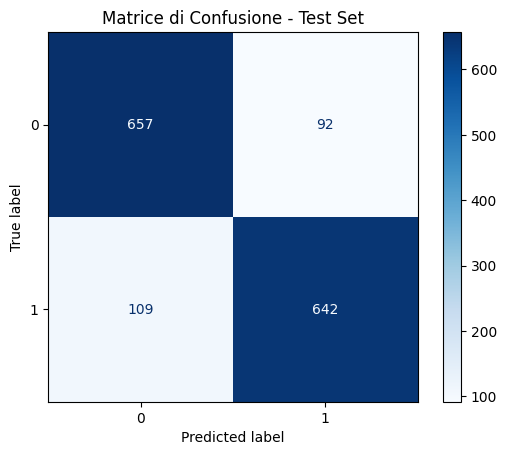

Valore AUC calcolato sul test set: 0.9294


/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


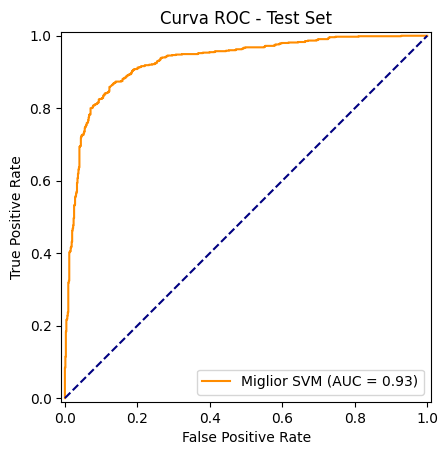

In [10]:
import matplotlib.pyplot as plt  # CORRETTO: Aggiunto l'import per i grafici
from numpy import sqrt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    ConfusionMatrixDisplay, 
    RocCurveDisplay
)

param_grid = [
    # Combinazioni per il kernel RBF
    {
        'kernel': ['rbf'],
        'C': [1, 1 / sqrt(len(X_tr))]
    },
    # Combinazioni per il kernel Polinomiale con i relativi gradi
    {
        'kernel': ['poly'],
        'C': [1, 1 / sqrt(len(X_tr))],
        'degree': [3, 4]
    }
]

search_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    scoring='accuracy' 
)

search_grid.fit(X_tr, y_tr)

best_model = search_grid.best_estimator_
best_params = search_grid.best_params_
best_cv_accuracy = search_grid.best_score_ 

print(f"Miglior classificatore (CV Accuracy): {best_cv_accuracy:.4f}")
print(f"Iperparametri ottimali: {best_params}")

name_model = f'parametri: {best_params}'

y_pred = best_model.predict(X_te)
y_pred_prob = best_model.predict_proba(X_te)[:, 1]

# NOTA: C'era un piccolo typo in test_accuracy (avevi scritto accurancy)
test_accuracy = accuracy_score(y_te, y_pred)
print(f"Test Accuracy ottenuta in predizione: {test_accuracy:.4f}")


cm = confusion_matrix(y_te, y_pred)

disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp_cm.plot(cmap=plt.cm.Blues)
plt.title("Matrice di Confusione - Test Set")
plt.show()


fpr, tpr, threshold = roc_curve(y_te, y_pred_prob)
roc_auc = auc(fpr, tpr)
print(f"Valore AUC calcolato sul test set: {roc_auc:.4f}")


disp_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Miglior SVM')
disp_roc.plot(color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title("Curva ROC - Test Set")
plt.show()